# 01 — Exploratory Data Analysis

Credit card customer transactions. Feeds **report §2 (Dataset Description)** and **§3 (Exploratory Business Analysis)**.

Two grains are loaded from the DVC pipeline outputs:
- `data/interim/cleaned.parquet` — **transaction level** (one row per transaction)
- `data/processed/customer_features.parquet` — **customer level** (one row per client)

Convention for this notebook (per the grading rubric): every chart title states the conclusion, and each section ends with a one-line quantified takeaway.

In [35]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

# Resolve repo root whether the notebook runs from notebooks/ or the root.
ROOT = Path.cwd()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent

txn = pd.read_parquet(ROOT / "data" / "interim" / "cleaned.parquet")
cust = pd.read_parquet(ROOT / "data" / "processed" / "customer_features.parquet")
print(f"transactions: {txn.shape[0]:,} rows x {txn.shape[1]} cols")
print(f"customers:    {cust.shape[0]:,} rows x {cust.shape[1]} cols")

transactions: 155,228 rows x 22 cols
customers:    996 rows x 23 cols


## 1. Data understanding & quality → report §2

In [36]:
# Dtypes and a first look at the transaction grain.
txn.info()
txn.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 155228 entries, 0 to 155227
Data columns (total 22 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   credit_limit       155228 non-null  int64         
 1   month_end_bal      155228 non-null  float64       
 2   txn_id             155228 non-null  int64         
 3   amount             155228 non-null  float64       
 4   merchant_category  155228 non-null  int64         
 5   merchant_name      155228 non-null  object        
 6   posting_date       155228 non-null  datetime64[ns]
 7   txn_date           155228 non-null  datetime64[ns]
 8   channel            116813 non-null  float64       
 9   date_opened        155228 non-null  datetime64[ns]
 10  card_type          155228 non-null  int64         
 11  total_cards        155228 non-null  int64         
 12  relationship       155228 non-null  object        
 13  gender             155228 non-null  int64   

,credit_limit,month_end_bal,txn_id,amount,merchant_category,merchant_name,posting_date,txn_date,channel,date_opened,card_type,total_cards,relationship,gender,race,customer_postcode,age,monthly_payment,customer_id_mask,txn_country,merchant_group,mall_group
0,40000,"16,596.84",4000,"2,688.00",8888,BUFFALO-12MTHS : 0/12 MY,2012-04-12,2012-04-01,NaN,2003-10-27,618,1,P,0,2,50490,38,"25,814.24",453806,None,IPP,Others
1,38000,"19,787.07",4000,89.27,5542,PSS BANDAR TASIK PUTERI,2012-04-01,2012-04-01,5.00,2003-06-21,429,1,P,0,2,47100,45,"1,950.00",335114,MY,Petrol,Others
2,8000,"1,143.89",2000,60.00,0,CASH PAYMENT AT D370,2012-04-01,2012-04-01,NaN,2010-10-01,13,0,P,0,1,89000,36,60.00,492071,None,None,Others
3,7000,"6,543.44",4000,22.76,5542,SHELL - TMN SETAPAK IN,2012-04-03,2012-04-01,5.00,2001-01-10,213,1,P,1,2,53000,62,250.00,192714,MY,Petrol,Others
4,6000,"5,381.41",4000,123.05,5411,CARREFOUR-KUANTAN,2012-04-03,2012-04-01,5.00,2006-06-21,213,1,P,1,2,25200,45,"4,600.00",337589,MY,Grocery,Others


In [37]:
# Time span covered by each date column (confirms the Julian YYYYDDD conversion is sane).
for col in ["txn_date", "posting_date", "date_opened"]:
    if col in txn.columns:
        print(f"{col:14s} {txn[col].min()}  ->  {txn[col].max()}")

txn_date       2012-04-01 00:00:00  ->  2014-03-28 00:00:00
posting_date   2012-04-01 00:00:00  ->  2014-03-28 00:00:00
date_opened    1988-11-04 00:00:00  ->  2014-03-06 00:00:00


In [38]:
# Missing values per column (transaction grain).
miss = txn.isna().mean().sort_values(ascending=False)
miss = (miss[miss > 0] * 100).round(1)
miss.to_frame("pct_missing")

,pct_missing
channel,24.70
txn_country,20.80
merchant_group,20.70


In [39]:
# Duplicates: is txn_id unique? Any fully duplicated rows?
if "txn_id" in txn.columns:
    print(f"distinct txn_id values:  {txn['txn_id'].nunique():,} (of {len(txn):,} rows)")
print(f"fully duplicated rows:   {txn.duplicated().sum():,}")
print(f"unique customers:        {txn['customer_id_mask'].nunique():,}")
sizes = txn.groupby('customer_id_mask').size()
print(f"transactions / customer: median={sizes.median():.0f}, max={sizes.max():,}")

distinct txn_id values:  9 (of 155,228 rows)
fully duplicated rows:   0
unique customers:        996
transactions / customer: median=104, max=1,512


### Categorical fields / mini data dictionary

Some fields are coded and undocumented (e.g. `gender='P'`, numeric `race`, blank `channel`/`txn_country`). Record the values here and treat undecodable codes as an explicit assumption in the report's limitations.

In [40]:
cat_cols = ["card_type", "relationship", "gender", "race", "channel",
            "merchant_group", "merchant_category", "txn_country", "mall_group"]
cat_cols = [c for c in cat_cols if c in txn.columns]

card = pd.DataFrame({
    "n_unique": [txn[c].nunique(dropna=True) for c in cat_cols],
    "pct_missing": [round(txn[c].isna().mean() * 100, 1) for c in cat_cols],
    "top_values": [txn[c].value_counts(dropna=False).head(5).to_dict() for c in cat_cols],
}, index=cat_cols)
card

,n_unique,pct_missing,top_values
card_type,146,0.00,"{500: 13824, 651: 11260, 547: 10950, 678: 8434..."
relationship,3,0.00,"{'P': 132834, 'M': 22299, 'C': 95}"
gender,2,0.00,"{1: 98264, 0: 56964}"
race,5,0.00,"{2: 88758, 1: 51790, 3: 10289, 4: 4121, 5: 270}"
channel,9,24.70,"{5.0: 86955, nan: 38415, 1.0: 12236, 0.0: 9010..."
merchant_group,51,20.70,"{None: 32065, 'Petrol': 31907, 'Insurance': 12..."
merchant_category,321,0.00,"{0: 32065, 5542: 28408, 5411: 11256, 5960: 793..."
txn_country,60,20.80,"{'MY': 113984, None: 32219, 'SG': 1451, 'GB': ..."
mall_group,22,0.00,"{'Others': 148225, 'MID VALLEY': 1090, 'ONE UT..."


In [41]:
# Impossible / sentinel value checks.
checks = {
    "amount <= 0": int((txn["amount"] <= 0).sum()),
    "amount is na": int(txn["amount"].isna().sum()),
    "age == 0 (cust)": int((cust["age"] == 0).sum()) if "age" in cust else np.nan,
    "credit_limit == 0 (cust)": int((cust["credit_limit"] == 0).sum()),
    "month_end_bal < 0 (cust)": int((cust["month_end_bal"] < 0).sum()),
    "utilisation > 1 (cust)": int((cust["credit_utilisation"] > 1).sum()),
    "postcode == 0 (cust)": int((cust["customer_postcode"] == 0).sum()) if "customer_postcode" in cust else np.nan,
}
pd.Series(checks, name="count").to_frame()

,count
amount <= 0,3
amount is na,0
age == 0 (cust),0
credit_limit == 0 (cust),4
month_end_bal < 0 (cust),51
utilisation > 1 (cust),21
postcode == 0 (cust),0


## 2. Distributions

`amount` is expected to be heavy-tailed — use a log scale and quantify the tail. Outliers flagged here drive the outlier-treatment decision that should feed back into `src/data/features.py`.

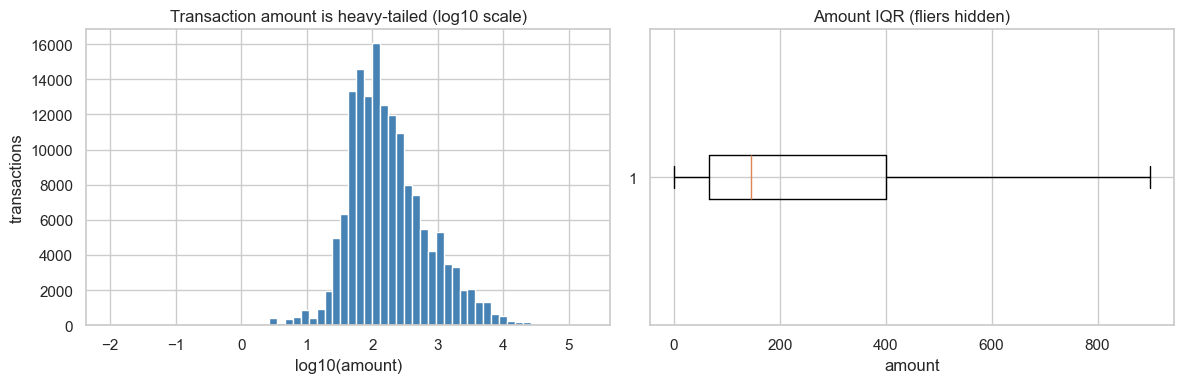

Takeaway: top 1% of transactions account for 28.9% of total spend.


In [52]:
amt = txn["amount"]
pos = amt[amt > 0]
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(np.log10(pos), bins=60, color="steelblue")
ax[0].set(title="Transaction amount is heavy-tailed (log10 scale)",
          xlabel="log10(amount)", ylabel="transactions")
ax[1].boxplot(pos, vert=False, showfliers=False)
ax[1].set(title="Amount IQR (fliers hidden)", xlabel="amount")
plt.tight_layout(); plt.show()

total = amt.sum()
top1 = amt.sort_values(ascending=False).head(max(1, int(len(amt) * 0.01))).sum()
print(f"Takeaway: top 1% of transactions account for {top1 / total:.1%} of total spend.")

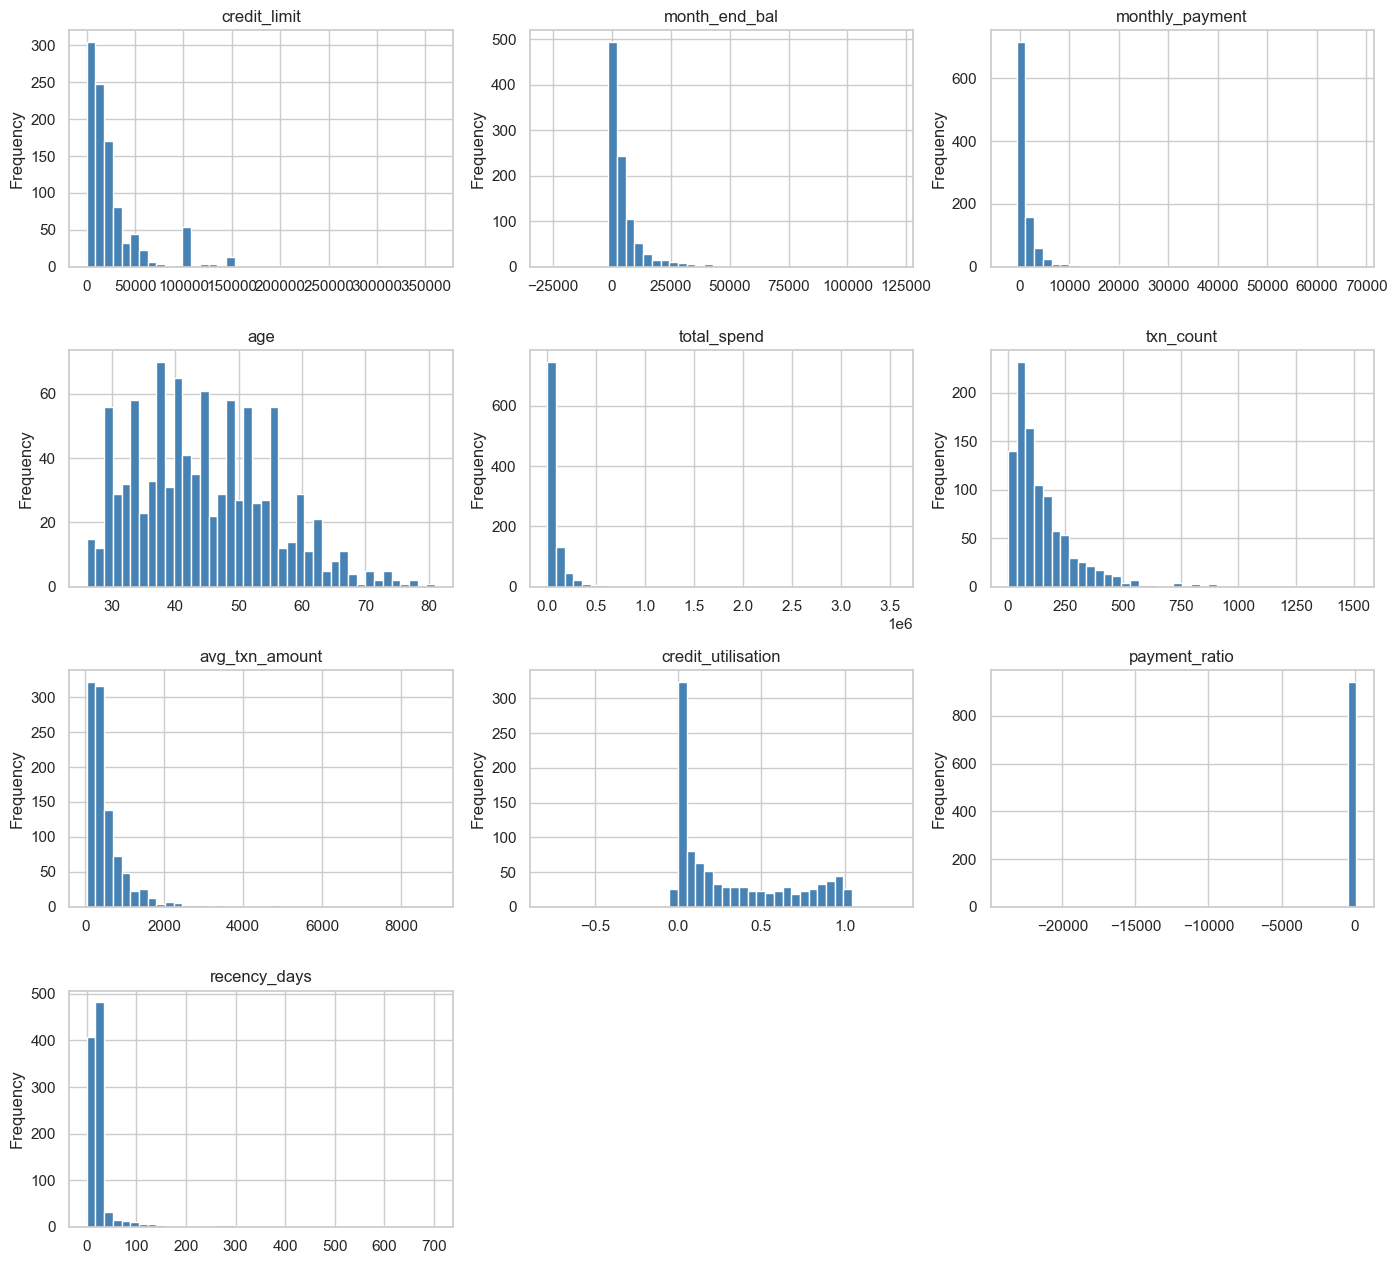

,count,mean,std,min,25%,50%,75%,max
credit_limit,996.00,"26,784.54","34,708.73",0.00,"7,000.00","16,000.00","30,000.00","360,000.00"
month_end_bal,996.00,"5,199.22","9,338.66","-27,515.32",389.81,"2,104.91","5,922.14","120,547.36"
monthly_payment,996.00,"1,522.87","4,507.12","-2,425.40",153.00,477.13,"1,251.50","68,000.00"
age,996.00,44.63,10.70,26.00,36.00,43.00,52.00,81.00
total_spend,996.00,"97,664.56","221,182.02",50.00,"17,462.58","39,441.30","89,004.92","3,558,964.87"
txn_count,996.00,155.85,163.62,1.00,58.00,104.00,197.00,"1,512.00"
avg_txn_amount,996.00,580.99,806.35,33.35,215.13,364.20,631.85,"8,865.69"
credit_utilisation,992.00,0.32,0.35,-0.79,0.02,0.16,0.61,1.31
payment_ratio,947.00,-42.53,861.76,"-23,715.00",0.05,0.12,0.72,121.56
recency_days,996.00,29.64,55.35,0.00,13.00,19.00,25.00,702.00


In [43]:
# Customer-level numeric distributions.
num_cols = ["credit_limit", "month_end_bal", "monthly_payment", "age",
            "total_spend", "txn_count", "avg_txn_amount", "credit_utilisation",
            "payment_ratio", "recency_days"]
num_cols = [c for c in num_cols if c in cust.columns]

n = len(num_cols)
rows = (n + 2) // 3
fig, axes = plt.subplots(rows, 3, figsize=(14, 3.2 * rows))
for ax, col in zip(axes.ravel(), num_cols):
    cust[col].plot.hist(bins=40, ax=ax, color="steelblue")
    ax.set_title(col)
for ax in axes.ravel()[n:]:
    ax.axis("off")
plt.tight_layout(); plt.show()
cust[num_cols].describe().T

## 3. Business EDA → report §3

Each cut below is tagged with the modelling track it informs.

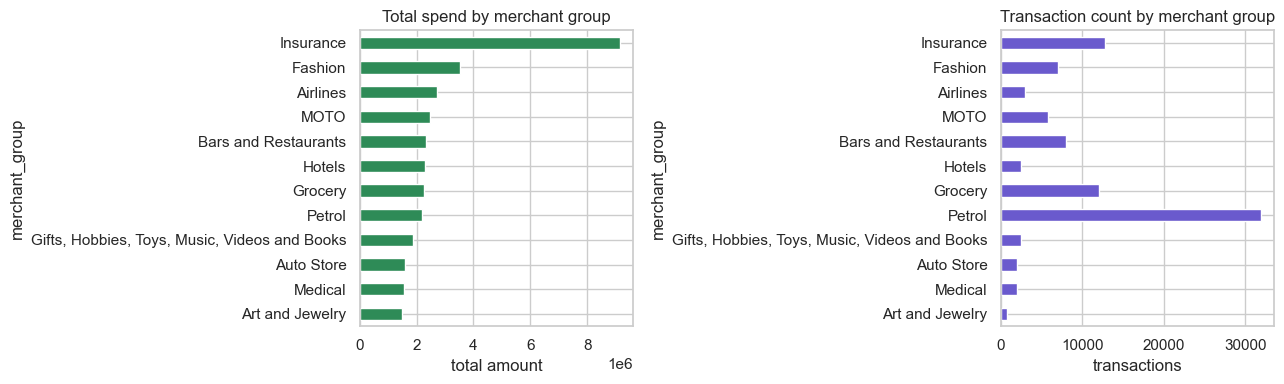

,sum,count,pct_of_spend
merchant_group,,,
Insurance,"9,154,815.52",12836,18.70
Fashion,"3,536,550.88",7049,7.20
Airlines,"2,704,483.68",2964,5.50
MOTO,"2,460,065.88",5763,5.00
Bars and Restaurants,"2,334,845.12",7964,4.80
Hotels,"2,311,626.74",2523,4.70
Grocery,"2,247,507.49",12006,4.60
Petrol,"2,208,336.05",31907,4.50
"Gifts, Hobbies, Toys, Music, Videos and Books","1,873,323.47",2494,3.80


In [44]:
# Spend by merchant group — value vs volume. (Segmentation: category-focused customers)
if "merchant_group" in txn.columns:
    mg = txn.groupby("merchant_group")["amount"].agg(["sum", "count"]).sort_values("sum", ascending=False)
    top = mg.head(12)
    fig, ax = plt.subplots(1, 2, figsize=(13, 4))
    top["sum"].plot.barh(ax=ax[0], color="seagreen"); ax[0].invert_yaxis()
    ax[0].set(title="Total spend by merchant group", xlabel="total amount")
    top["count"].plot.barh(ax=ax[1], color="slateblue"); ax[1].invert_yaxis()
    ax[1].set(title="Transaction count by merchant group", xlabel="transactions")
    plt.tight_layout(); plt.show()
    display(mg.assign(pct_of_spend=(mg["sum"] / mg["sum"].sum() * 100).round(1)).head(10))

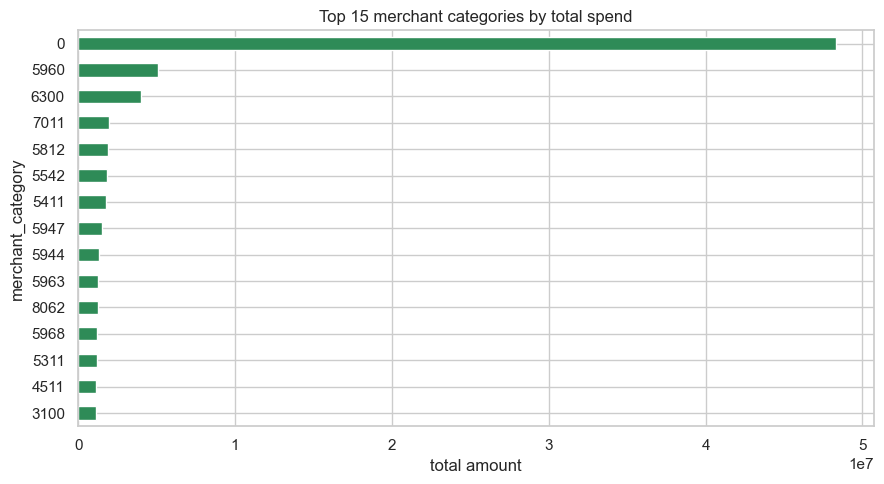

In [45]:
# Top merchant categories by spend. (Segmentation / merchant promos)
if "merchant_category" in txn.columns:
    mc = txn.groupby("merchant_category")["amount"].sum().sort_values(ascending=False).head(15)
    mc.sort_values().plot.barh(figsize=(9, 5), color="seagreen")
    plt.title("Top 15 merchant categories by total spend"); plt.xlabel("total amount")
    plt.tight_layout(); plt.show()

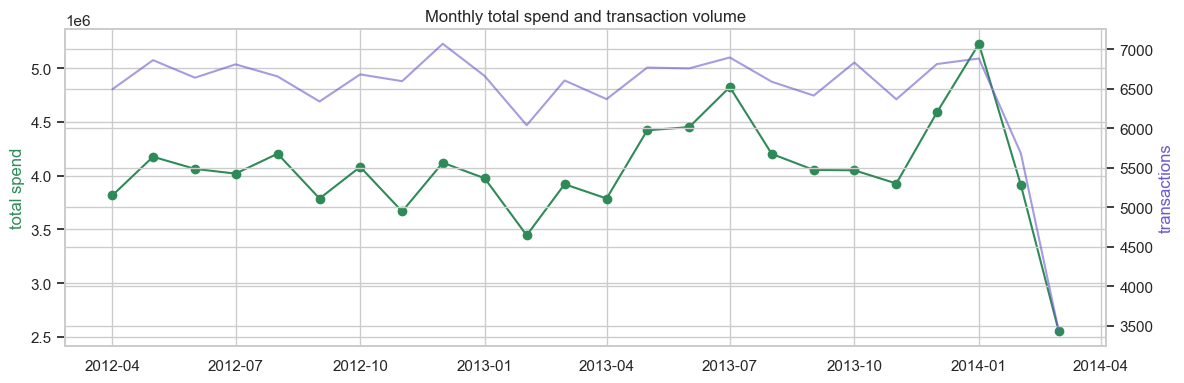

Note: check whether the first/last months are partial — affects the churn window and forecasting.


,sum,count
txn_date,,
2013-10-01,"4,050,168.97",6831
2013-11-01,"3,927,109.42",6366
2013-12-01,"4,589,314.61",6812
2014-01-01,"5,227,412.16",6882
2014-02-01,"3,911,637.87",5680
2014-03-01,"2,550,351.45",3429


In [46]:
# Monthly spend and transaction volume over time. (Forecasting + churn-window context)
monthly = (txn.dropna(subset=["txn_date"])
              .set_index("txn_date")
              .resample("MS")["amount"].agg(["sum", "count"]))
fig, ax1 = plt.subplots(figsize=(12, 4))
ax1.plot(monthly.index, monthly["sum"], color="seagreen", marker="o", label="total spend")
ax1.set_ylabel("total spend", color="seagreen")
ax2 = ax1.twinx()
ax2.plot(monthly.index, monthly["count"], color="slateblue", alpha=0.6, label="transactions")
ax2.set_ylabel("transactions", color="slateblue")
ax1.set_title("Monthly total spend and transaction volume")
plt.tight_layout(); plt.show()
print("Note: check whether the first/last months are partial — affects the churn window and forecasting.")
monthly.tail(6)

In [47]:
# Behaviour by customer attributes. (Segmentation / Regression)
cust2 = cust.copy()
if "age" in cust2.columns:
    cust2["age_band"] = pd.cut(cust2["age"], bins=[0, 25, 35, 45, 55, 65, 200],
                                labels=["<25", "25-34", "35-44", "45-54", "55-64", "65+"])
for dim in ["card_type", "relationship", "age_band"]:
    if dim in cust2.columns:
        g = cust2.groupby(dim, observed=True).agg(
            customers=("total_spend", "size"),
            mean_spend=("total_spend", "mean"),
            mean_utilisation=("credit_utilisation", "mean"))
        print(f"\n=== by {dim} ==="); display(g.round(2))


=== by card_type ===


,customers,mean_spend,mean_utilisation
card_type,,,
7,3,"49,552.33",0.18
13,9,"370,606.09",0.19
107,4,"24,251.89",0.50
109,2,"174,979.40",0.52
110,2,"29,311.46",0.12
...,...,...,...
819,31,"341,595.67",0.20
850,1,"16,212.85",0.00
857,1,"98,002.15",0.00



=== by relationship ===


,customers,mean_spend,mean_utilisation
relationship,,,
C,1,"55,674.47",0.08
M,66,"195,513.07",0.19
P,929,"90,758.20",0.33



=== by age_band ===


,customers,mean_spend,mean_utilisation
age_band,,,
25-34,225,"72,512.50",0.40
35-44,336,"95,493.31",0.36
45-54,263,"107,999.53",0.29
55-64,138,"128,000.28",0.17
65+,34,"82,497.77",0.13


In [48]:
# RFM snapshot — the docs' recommended segmentation starting point. (Segmentation)
rfm = cust[["recency_days", "txn_count", "total_spend"]].rename(
    columns={"recency_days": "Recency", "txn_count": "Frequency", "total_spend": "Monetary"})
rfm.describe(percentiles=[.25, .5, .75, .9]).T

,count,mean,std,min,25%,50%,75%,90%,max
Recency,996.00,29.64,55.35,0.00,13.00,19.00,25.00,37.50,702.00
Frequency,996.00,155.85,163.62,1.00,58.00,104.00,197.00,337.00,"1,512.00"
Monetary,996.00,"97,664.56","221,182.02",50.00,"17,462.58","39,441.30","89,004.92","203,849.96","3,558,964.87"


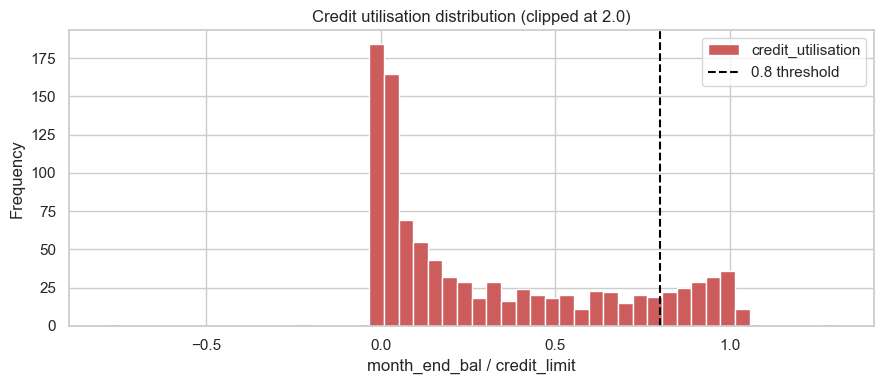

Takeaway: 16.0% of customers have utilisation above 0.8 (high-risk band).


In [49]:
# Credit utilisation distribution. (Classification: risk-sensitive customers)
util = cust["credit_utilisation"].clip(upper=2)
util.plot.hist(bins=50, figsize=(9, 4), color="indianred")
plt.axvline(0.8, color="black", ls="--", label="0.8 threshold")
plt.title("Credit utilisation distribution (clipped at 2.0)"); plt.xlabel("month_end_bal / credit_limit")
plt.legend(); plt.tight_layout(); plt.show()
high = (cust["credit_utilisation"] > 0.8).mean()
print(f"Takeaway: {high:.1%} of customers have utilisation above 0.8 (high-risk band).")

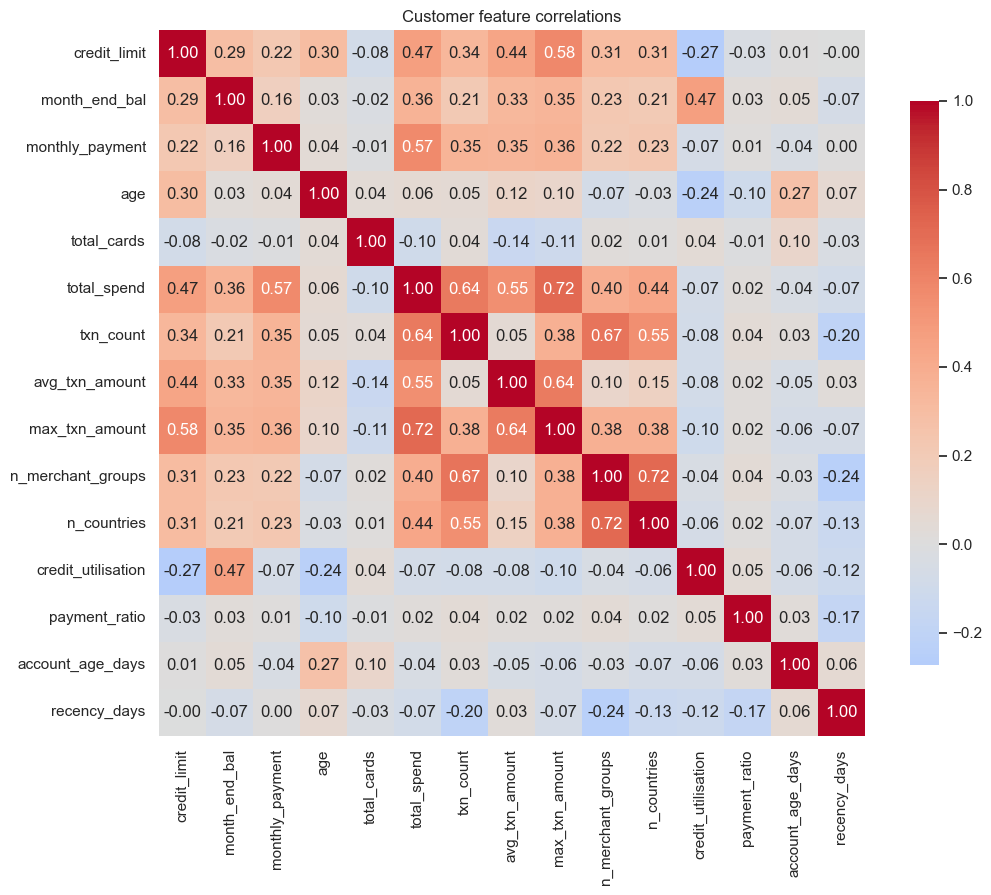

In [50]:
# Correlation of customer-level numeric features (informs PCA / multicollinearity). (Regression)
corr_cols = ["credit_limit", "month_end_bal", "monthly_payment", "age", "total_cards",
             "total_spend", "txn_count", "avg_txn_amount", "max_txn_amount",
             "n_merchant_groups", "n_countries", "credit_utilisation",
             "payment_ratio", "account_age_days", "recency_days"]
corr_cols = [c for c in corr_cols if c in cust.columns]
plt.figure(figsize=(11, 9))
sns.heatmap(cust[corr_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm",
            center=0, square=True, cbar_kws={"shrink": .8})
plt.title("Customer feature correlations"); plt.tight_layout(); plt.show()

## 4. Churn-proxy validation

The churn label in `features.py` flags customers with no transaction in the most recent `recent_activity_months`. Check the resulting rate is defensible; if not, change the param in `params.yaml` and `dvc repro`.

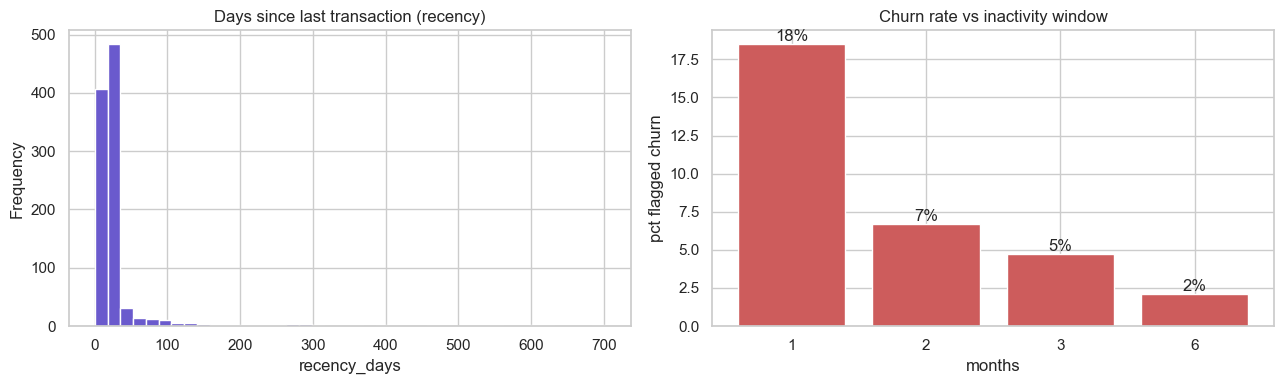

as_of=2014-03-28; current label uses the 1-month window.


In [51]:
# Recency distribution + churn rate vs window length.
as_of = txn["txn_date"].max()
last = txn.groupby("customer_id_mask")["txn_date"].max()

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
cust["recency_days"].plot.hist(bins=40, ax=ax[0], color="slateblue")
ax[0].set(title="Days since last transaction (recency)", xlabel="recency_days")

windows = [1, 2, 3, 6]
rates = [(last < (as_of - pd.DateOffset(months=m))).mean() for m in windows]
ax[1].bar([str(m) for m in windows], [r * 100 for r in rates], color="indianred")
ax[1].set(title="Churn rate vs inactivity window", xlabel="months", ylabel="pct flagged churn")
for i, r in enumerate(rates):
    ax[1].text(i, r * 100, f"{r:.0%}", ha="center", va="bottom")
plt.tight_layout(); plt.show()
print(f"as_of={as_of.date()}; current label uses the 1-month window.")

## 5. Ethics note → rubric Critical Thinking

The dataset contains `race` and `gender`. These will be **excluded from all predictive models** to avoid encoding demographic bias into customer-value, churn, or segmentation decisions; they may appear only in descriptive analysis with care. Note this explicitly in report §9 (Limitations / Ethics).

## 6. Key findings

**Data quality**
- After cleaning, the panel is **155,228 transactions / 996 customers / 24 months** (2012-04 to 2014-03) with **no missing values in any modelling feature**.
- **1,190 byte-identical duplicate rows** were dropped as export artifacts (no true transaction key — `txn_id` has only 9 distinct values).
- Missing categoricals: `channel` 24.7%, `txn_country` 20.8%, `merchant_group` 20.7%; handled per analysis. A few sentinel/edge values (3 txns `amount`≤0; `payment_ratio` to −23,715 from negative balances) are isolated and neutralised in modelling.

**Spending & customer behaviour**
- Spend is **highly concentrated**: the top 1% of transactions = **28.9%** of spend; customer total spend is right-skewed (median \$39k vs mean \$98k).
- **Value ≠ volume** by merchant: Insurance leads value (\$9.15M, 9.4% of spend) on few transactions; Petrol leads volume (31,907 txns) at just \$69 average.
- Spend grew **+29%** to a Jan-2014 peak (\$5.23M); the final month (Mar-2014) is **partial** and must be excluded from forecasts and the churn window.
- **16% of customers** sit above 0.8 credit utilisation (high-risk band).

**Implications per track**
- **Segmentation:** heavy skew must be de-skewed (winsorise + power transform) or K-Means collapses to a trivial whales-vs-rest split.
- **Regression (CLTV):** exclude spend-arithmetic features (they reconstruct the target); predict value from account attributes.
- **Classification (churn):** exclude `recency_days`/`last_txn_date` (they define the label); ~18.5% positive rate → use balanced weights, prioritise recall.
- **Forecasting:** trim the partial last month; with ~2 years of flat-ish monthly data, expect simple baselines to be competitive.